## Batch Normalization in Deep Learning

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

tf.keras.utils.set_random_seed(42)

X, y = make_moons(n_samples=2000, noise=0.25, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [2]:
def build_model(use_batch_norm=False):
    model = Sequential()

    model.add(Dense(128, input_shape=(2,), use_bias=not use_batch_norm))

    if use_batch_norm:
        model.add(BatchNormalization())

    model.add(Activation("relu"))

    model.add(Dense(128, use_bias=not use_batch_norm))

    if use_batch_norm:
        model.add(BatchNormalization())

    model.add(Activation("relu"))
    model.add(Dense(64, activation="relu"))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [3]:
models = {
    "Without BatchNorm": build_model(False),
    "With BatchNorm": build_model(True)
}

histories = {}
results = {}

for name, model in models.items():
    tf.keras.backend.clear_session()

    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )

    histories[name] = history.history
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    results[name] = {
        "Test Loss": loss,
        "Test Accuracy": accuracy
    }

print(results)

c:\Users\alili\100_days_Deep_Learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



{'Without BatchNorm': {'Test Loss': 0.17661583423614502, 'Test Accuracy': 0.9200000166893005}, 'With BatchNorm': {'Test Loss': 0.17804154753684998, 'Test Accuracy': 0.9275000095367432}}


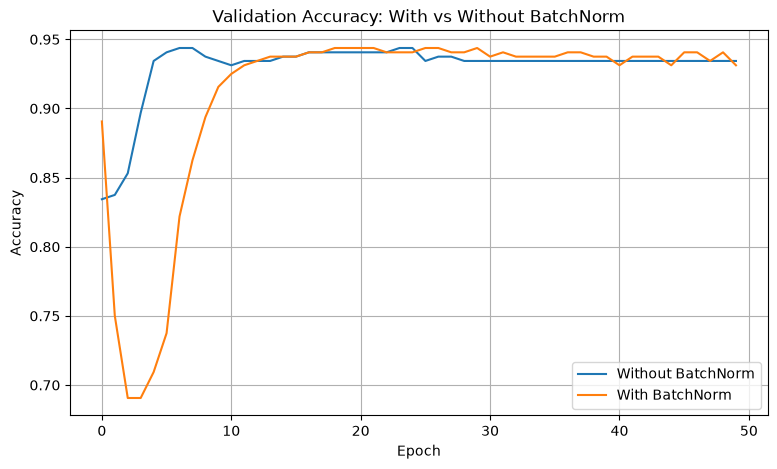

In [4]:
plt.figure(figsize=(9, 5))

for name, history in histories.items():
    plt.plot(history["val_accuracy"], label=name)

plt.title("Validation Accuracy: With vs Without BatchNorm")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

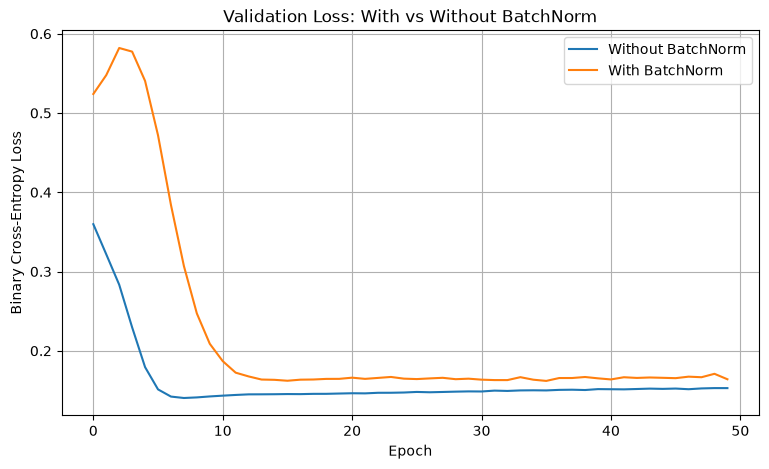

In [5]:
plt.figure(figsize=(9, 5))

for name, history in histories.items():
    plt.plot(history["val_loss"], label=name)

plt.title("Validation Loss: With vs Without BatchNorm")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid()
plt.show()